In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import random
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter

In [2]:
# Paths
DATA_DIR = Path('../../data')
DATA_FILES_DIR = DATA_DIR / 'data_files'
LABELS_FILE = DATA_DIR / 'data_info' / 'data_roster.csv'

IMAGE_HEIGHT = 132
IMAGE_WIDTH = 164

print(f"Data directory exists: {DATA_FILES_DIR.exists()}")
print(f"Labels file exists: {LABELS_FILE.exists()}")

Data directory exists: True
Labels file exists: True


In [3]:
# Load labels
labels_df = pd.read_csv(LABELS_FILE, index_col=0)
print(f"Labels dataframe shape: {labels_df.shape}")
labels_df.head()

Labels dataframe shape: (16478, 12)


,file_name,label_v1,3-agree,label_v2,label_v3,excitation_position,excitation_PIE,excitation_quality,soldet_CNN,soldet_OD,soldet_PIE,soldet_QE
/data/data_files/class-1/2019-08-02_0004_20190523_BEC_F1_NewODT_DMD_42.npy,/data/data_files/class-1/2019-08-02_0004_20190...,1,1,1,1,[110.35077157540614],[1],[0.7305203942861915],NaN,NaN,NaN,NaN
/data/data_files/class-1/2019-07-19_0028_20190523_BEC_F1_NewODT_DMD_037.npy,/data/data_files/class-1/2019-07-19_0028_20190...,1,0,1,1,[41.63773334829051],[1],[0.24901817761481015],NaN,NaN,NaN,NaN
/data/data_files/class-0/2019-07-16_0012_20190523_BEC_F1_NewODT_DMD_208.npy,/data/data_files/class-0/2019-07-16_0012_20190...,0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
/data/data_files/class-2/2019-07-15_0011_20190523_BEC_F1_NewODT_DMD_025.npy,/data/data_files/class-2/2019-07-15_0011_20190...,2,1,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
/data/data_files/class-0/2019-07-12_0061_20190523_BEC_F1_NewODT_DMD_109.npy,/data/data_files/class-0/2019-07-12_0061_20190...,0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
def _class_sort_key(path_obj):
    suffix = path_obj.name.split('-')[-1]
    return int(suffix) if suffix.isdigit() else suffix


def _discover_class_dirs(data_dir):
    class_dirs = [d for d in data_dir.glob('class-*') if d.is_dir()]
    return sorted(class_dirs, key=_class_sort_key)


def _collect_npy_files(class_dirs):
    all_files = []
    for class_dir in class_dirs:
        all_files.extend(sorted(class_dir.glob('*.npy')))
    return all_files


def _shuffle_and_limit_files(all_files, shuffle_seed=None, max_samples=None):
    files = list(all_files)
    if shuffle_seed is not None:
        random.seed(shuffle_seed)
        random.shuffle(files)
    if max_samples is not None:
        files = files[:max_samples]
    return files


def _safe_parse_positions(pos_str):
    if pd.isna(pos_str) or pos_str == '':
        return []
    try:
        pos = eval(pos_str) if isinstance(pos_str, str) else []
        if not isinstance(pos, list):
            return [pos] if pos else []
        return pos
    except Exception:
        return []


def _load_single_sample(file_path, labels_df):
    data_dict = np.load(file_path, allow_pickle=True).item()
    img = data_dict['cloud_data'].reshape(IMAGE_HEIGHT, IMAGE_WIDTH, 1)

    rel_path = '/data/' + '/'.join(file_path.parts[-3:])
    if rel_path not in labels_df.index:
        return None

    label_row = labels_df.loc[rel_path]
    label = int(label_row['label_v3'])
    pos = _safe_parse_positions(label_row['excitation_position'])
    return img.astype(np.float32), label, pos, str(file_path)


def _summarize_dataset(images, labels):
    print(f"Loaded {len(images)} images")
    print(f"Image shape: {images.shape}")
    print(f"Value range: [{images.min():.3f}, {images.max():.3f}]")
    print(f"Label distribution: {np.bincount(labels)}")


def load_bec_dataset(data_dir, labels_df, max_samples=None, shuffle_seed=42):
    """Load BEC images + labels from data_files and data_roster.csv."""
    class_dirs = _discover_class_dirs(data_dir)
    print(f"Discovered class folders: {[d.name for d in class_dirs]}")

    all_files = _collect_npy_files(class_dirs)
    print(f"Found {len(all_files)} .npy files")

    all_files = _shuffle_and_limit_files(
        all_files,
        shuffle_seed=shuffle_seed,
        max_samples=max_samples,
    )

    images = []
    labels = []
    positions = []
    file_paths = []

    print(f"Loading {len(all_files)} samples...")
    for file_path in tqdm(all_files):
        try:
            sample = _load_single_sample(file_path, labels_df)
            if sample is None:
                continue
            img, label, pos, file_path_str = sample
            images.append(img)
            labels.append(label)
            positions.append(pos)
            file_paths.append(file_path_str)
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
            continue

    images = np.array(images, dtype=np.float32)
    labels = np.array(labels, dtype=np.int32)

    _summarize_dataset(images, labels)
    return images, labels, positions, file_paths

In [33]:
# Load dataset
images, labels, positions, file_paths = load_bec_dataset(
    DATA_FILES_DIR,
    labels_df,
    max_samples=6000,
    shuffle_seed=42,
    )

print(f"Unique labels: {np.unique(labels)}")
print(f"images dtype: {images.dtype}")

Discovered class folders: ['class-0', 'class-1', 'class-2', 'class-8', 'class-9']
Found 16478 .npy files
Loading 6000 samples...


100%|██████████| 6000/6000 [00:41<00:00, 145.53it/s]


Loaded 6000 images
Image shape: (6000, 132, 164, 1)
Value range: [-0.469, 2.965]
Label distribution: [ 425 1180  375    0    0    0    0    0  316 3704]
Unique labels: [0 1 2 8 9]
images dtype: float32


In [20]:
# Utility: pick one anchor image index for parameter fitting
anchor_idx = 12
print(f"Anchor sample index: {anchor_idx}")

Anchor sample index: 12


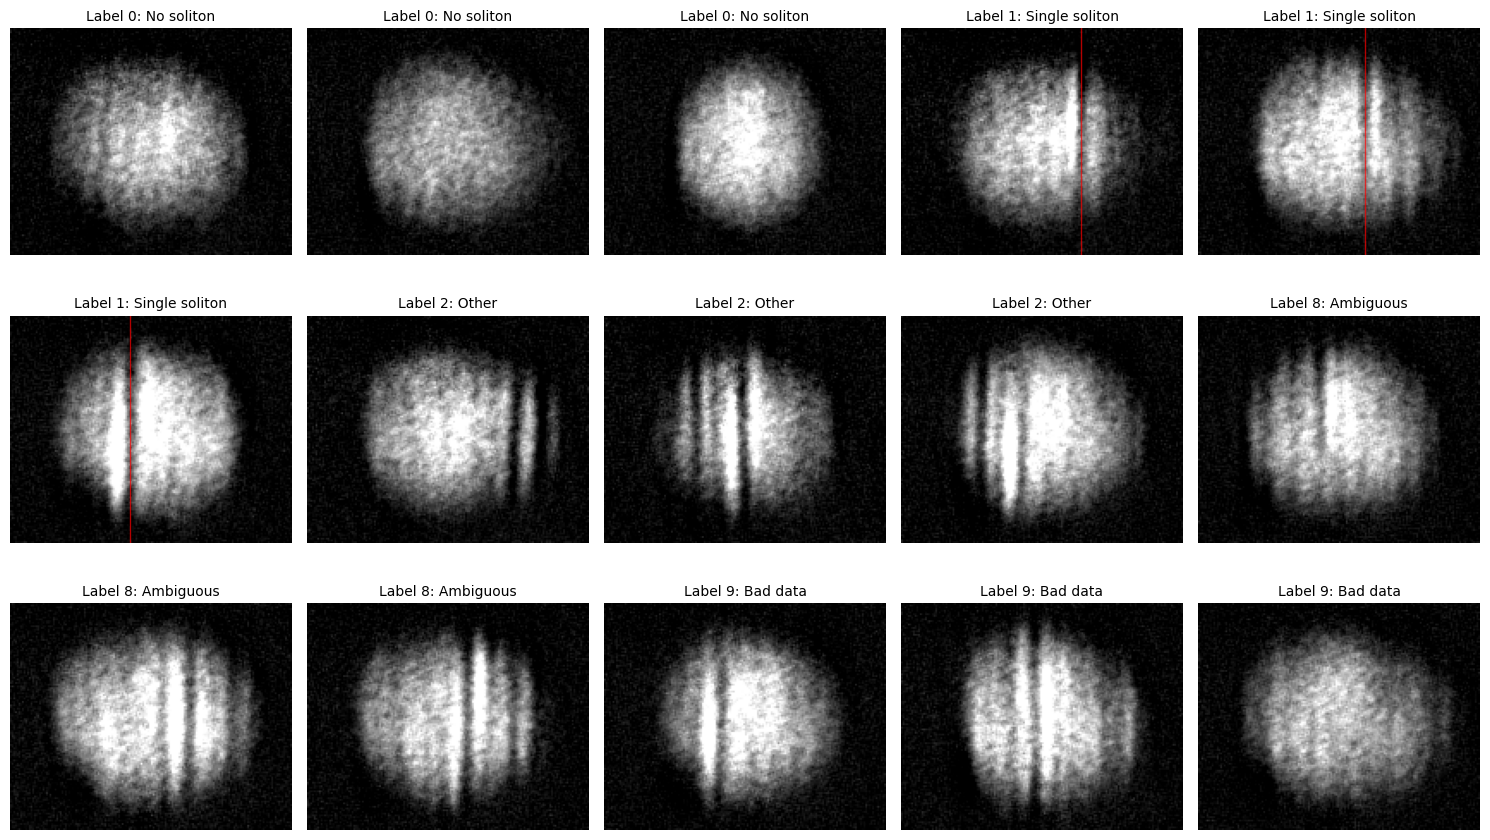

In [34]:
# Preview a few real images
def _label_names():
    return {
        0: 'No soliton',
        1: 'Single soliton',
        2: 'Other',
        8: 'Ambiguous',
        9: 'Bad data',
    }


def _compute_preview_layout(max_total_plots=15, n_cols=5):
    n_rows = int(np.ceil(max_total_plots / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 9))
    return fig, axes.flatten()


def _pick_indices_for_label(labels, label_val, samples_per_class):
    indices = np.where(labels == label_val)[0]
    return indices[:min(samples_per_class, len(indices))]


def _draw_position_markers(ax, sample_positions):
    if len(sample_positions) == 0:
        return
    for pos in sample_positions:
        ax.axvline(x=pos, color='red', linewidth=1, alpha=0.7)


def _plot_preview_image(ax, image_2d, label_val, label_names, sample_positions):
    ax.imshow(image_2d, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"Label {label_val}: {label_names.get(label_val, f'Class {label_val}')}", fontsize=10)
    ax.axis('off')
    _draw_position_markers(ax, sample_positions)


def _hide_unused_axes(axes, start_idx):
    for idx in range(start_idx, len(axes)):
        axes[idx].axis('off')


def plot_dataset_preview(labels, images, positions, samples_per_class=3, max_total_plots=15, n_cols=5):
    class_values = sorted(np.unique(labels).tolist())
    label_names = _label_names()
    fig, axes = _compute_preview_layout(max_total_plots=max_total_plots, n_cols=n_cols)

    plot_idx = 0
    for label_val in class_values:
        sample_indices = _pick_indices_for_label(labels, label_val, samples_per_class)
        for idx in sample_indices:
            if plot_idx >= max_total_plots:
                break
            _plot_preview_image(
                axes[plot_idx],
                images[idx].squeeze(),
                label_val,
                label_names,
                positions[idx],
            )
            plot_idx += 1
        if plot_idx >= max_total_plots:
            break

    _hide_unused_axes(axes, plot_idx)
    plt.tight_layout()
    plt.show()


plot_dataset_preview(labels, images, positions)

In [35]:
# Thomas-Fermi model and fitting helpers
def thomas_fermi_2d(coords, n0, i0, j0, Ri, Rj, theta, delta_n):
    i, j = coords
    di = i - i0
    dj = j - j0

    cos_t = np.cos(theta)
    sin_t = np.sin(theta)
    i_theta = cos_t * di + sin_t * dj
    j_theta = -sin_t * di + cos_t * dj

    inside = 1.0 - (i_theta / Ri) ** 2 - (j_theta / Rj) ** 2
    tf_core = np.maximum(inside, 0.0) ** 1.5
    return n0 * tf_core + delta_n


def _fit_grids(image_2d):
    h, w = image_2d.shape
    return h, w, np.indices((h, w))


def _fit_data_range(image_2d):
    data_min = float(np.min(image_2d))
    data_max = float(np.max(image_2d))
    data_range = max(data_max - data_min, 1e-6)
    return data_min, data_max, data_range


def _initial_tf_guess(h, w, data_min, data_range):
    return np.array([
        data_range,
        (h - 1) / 2.0,
        (w - 1) / 2.0,
        max(h / 3.0, 1.0),
        max(w / 3.0, 1.0),
        0.0,
        data_min,
    ], dtype=float)


def _tf_bounds(h, w, data_min, data_max, data_range):
    lower = np.array([0.0, 0.0, 0.0, 1.0, 1.0, -np.pi / 2, data_min - 0.5 * data_range], dtype=float)
    upper = np.array([data_max + 2.0 * data_range, h - 1.0, w - 1.0, 2.0 * h, 2.0 * w, np.pi / 2, data_max], dtype=float)
    return lower, upper


def _clamp_guess_to_bounds(p0, lower, upper):
    eps = 1e-9
    return np.minimum(np.maximum(p0, lower + eps), upper - eps)


def _solve_tf_params(i_grid, j_grid, image_2d, p0, lower, upper):
    popt, _ = curve_fit(
        thomas_fermi_2d,
        (i_grid.ravel(), j_grid.ravel()),
        image_2d.ravel(),
        p0=p0,
        bounds=(lower, upper),
        method='trf',
        maxfev=30000,
    )
    return popt


def fit_thomas_fermi_image(image_2d):
    h, w, (i_grid, j_grid) = _fit_grids(image_2d)
    data_min, data_max, data_range = _fit_data_range(image_2d)
    p0 = _initial_tf_guess(h, w, data_min, data_range)
    lower, upper = _tf_bounds(h, w, data_min, data_max, data_range)
    p0 = _clamp_guess_to_bounds(p0, lower, upper)
    popt = _solve_tf_params(i_grid, j_grid, image_2d, p0, lower, upper)

    fitted = thomas_fermi_2d((i_grid, j_grid), *popt)
    residual = image_2d - fitted
    return popt, fitted, residual


def _sample_tf_param_offsets(rng):
    return [
        rng.uniform(0.9, 1.1),
        rng.uniform(-3.0, 3.0),
        rng.uniform(-3.0, 3.0),
        rng.uniform(0.9, 1.1),
        rng.uniform(0.9, 1.1),
        rng.uniform(-0.12, 0.12),
        rng.uniform(-0.01, 0.01),
    ]


def _apply_tf_offsets(tf_params, offsets):
    n0, i0, j0, Ri, Rj, theta, delta_n = tf_params
    n0_scale, i0_shift, j0_shift, Ri_scale, Rj_scale, theta_shift, delta_n_shift = offsets
    return [
        n0 * n0_scale,
        i0 + i0_shift,
        j0 + j0_shift,
        Ri * Ri_scale,
        Rj * Rj_scale,
        theta + theta_shift,
        delta_n + delta_n_shift,
    ]


def sample_thomas_fermi_cloud(tf_params, shape=(IMAGE_HEIGHT, IMAGE_WIDTH), rng=None):
    if rng is None:
        rng = np.random.default_rng()

    sampled = _apply_tf_offsets(tf_params, _sample_tf_param_offsets(rng))
    h, w = shape
    i_grid, j_grid = np.indices((h, w))
    cloud = thomas_fermi_2d((i_grid, j_grid), *sampled)
    return np.clip(cloud, 0.0, 1.0), sampled

In [36]:
# Simulation components: soliton, diffraction, shot noise, read noise
def _line_coordinates(h, w, i0, j0, angle_rad):
    i_grid, j_grid = np.indices((h, w))
    d = (j_grid - j0) * np.cos(angle_rad) - (i_grid - i0) * np.sin(angle_rad)
    t = (j_grid - j0) * np.sin(angle_rad) + (i_grid - i0) * np.cos(angle_rad)
    return i_grid, j_grid, d, t


def _compute_y_fade(t, y_fade_px, y_fade_power):
    if y_fade_px is None or y_fade_px <= 0:
        return 1.0
    t_scale = max(float(y_fade_px), 1e-3)
    fade_power = max(float(y_fade_power), 1e-3)
    return np.exp(-0.5 * (np.abs(t) / t_scale) ** fade_power)


def _compute_notch(d, width_px, y_fade):
    width_eff = max(float(width_px), 1e-3)
    notch = np.exp(-(d ** 2) / (2.0 * width_eff ** 2))
    return notch * y_fade


def _compute_ringing(d, y_fade, fringe_period_px, fringe_decay_px, fringe_phase):
    period = max(float(fringe_period_px), 1e-3)
    decay = max(float(fringe_decay_px), 1e-3)
    envelope = np.exp(-(d ** 2) / (2.0 * decay ** 2)) * y_fade
    return -np.cos((2.0 * np.pi * d / period) + fringe_phase) * envelope


def _compute_asymmetry_modulation(
    i_grid,
    j_grid,
    i0,
    j0,
    d,
    side_antisym,
    side_antisym_scale_px,
    diagonal_antisym,
    diagonal_antisym_scale_px,
    diagonal_angle_rad,
    ):
    side_scale = max(float(side_antisym_scale_px), 1e-3)
    side_field = np.tanh(d / side_scale)

    ii = i_grid - i0
    jj = j_grid - j0
    x_diag = jj * np.cos(diagonal_angle_rad) - ii * np.sin(diagonal_angle_rad)
    y_diag = jj * np.sin(diagonal_angle_rad) + ii * np.cos(diagonal_angle_rad)
    diag_scale = max(float(diagonal_antisym_scale_px), 1e-3)
    diag_field = np.tanh((x_diag * y_diag) / (diag_scale ** 2))

    amplitude_mod = 1.0 + side_antisym * side_field + diagonal_antisym * diag_field
    return np.clip(amplitude_mod, 0.0, 2.5)


def add_dark_soliton_excitation(
    image,
    i0,
    j0,
    angle_rad=0.0,
    depth=0.70,
    width_px=3.0,
    fringe_gain=0.14,
    fringe_period_px=7.0,
    fringe_decay_px=10.0,
    fringe_phase=0.0,
    side_antisym=0.0,
    side_antisym_scale_px=4.0,
    diagonal_antisym=0.0,
    diagonal_antisym_scale_px=12.0,
    diagonal_angle_rad=0.0,
    y_fade_px=None,
    y_fade_power=2.0,
    ):
    """Dark soliton notch with optional side-lobe ringing and asymmetry."""
    h, w = image.shape
    i_grid, j_grid, d, t = _line_coordinates(h, w, i0, j0, angle_rad)
    y_fade = _compute_y_fade(t, y_fade_px, y_fade_power)
    notch = _compute_notch(d, width_px, y_fade)
    depletion = image * (1.0 - depth * notch)

    if fringe_gain is None or fringe_gain <= 0:
        return np.clip(depletion, 0.0, 1.0)

    ringing = _compute_ringing(d, y_fade, fringe_period_px, fringe_decay_px, fringe_phase)
    amplitude_mod = _compute_asymmetry_modulation(
        i_grid,
        j_grid,
        i0,
        j0,
        d,
        side_antisym,
        side_antisym_scale_px,
        diagonal_antisym,
        diagonal_antisym_scale_px,
        diagonal_angle_rad,
    )
    ringing = np.clip(ringing * amplitude_mod, -1.0, 1.0)
    out = depletion + fringe_gain * ringing * image
    return np.clip(out, 0.0, 1.0)


def _fresnel_transfer_function(h, w, pixel_size, wavelength, propagation_distance, na):
    fy = np.fft.fftfreq(h, d=pixel_size)
    fx = np.fft.fftfreq(w, d=pixel_size)
    FX, FY = np.meshgrid(fx, fy)
    H = np.exp(-1j * np.pi * wavelength * propagation_distance * (FX**2 + FY**2))

    if na is not None and na > 0:
        f_cut = na / wavelength
        H = H * ((FX**2 + FY**2) <= (f_cut**2))
    return H


def _normalize_unit_interval(image):
    shifted = image - image.min()
    max_val = shifted.max()
    if max_val > 0:
        shifted = shifted / max_val
    return shifted


def apply_fresnel_diffraction(
    image, wavelength=780e-9, pixel_size=5.6e-6, propagation_distance=2.0e-3, phase_scale=1.2, blend=0.7, na=0.22
    ):
    img = np.clip(image.astype(np.float64), 0.0, 1.0)
    h, w = img.shape

    amplitude = np.sqrt(img + 1e-8)
    phase = phase_scale * img
    field0 = amplitude * np.exp(1j * phase)

    H = _fresnel_transfer_function(h, w, pixel_size, wavelength, propagation_distance, na)
    field_z = np.fft.ifft2(np.fft.fft2(field0) * H)
    intensity_z = _normalize_unit_interval(np.abs(field_z) ** 2)

    out = (1.0 - blend) * img + blend * intensity_z
    return np.clip(out, 0.0, 1.0)


def add_shot_noise(image, photons_per_pixel=5, rng=None):
    """Poisson shot noise: variance grows with intensity."""
    if rng is None:
        rng = np.random.default_rng()
    img = np.clip(image, 0.0, 1.0)
    expected_counts = img * photons_per_pixel
    noisy_counts = rng.poisson(expected_counts)
    return noisy_counts / max(float(photons_per_pixel), 1e-9)


def add_read_noise(image, read_noise_std=0.01, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    return image + rng.normal(0.0, read_noise_std, size=image.shape)


def add_shift(image, max_shift_px=5.0, apply_prob=0.9, blend=0.5, rng=None):
    """Apply optional ghosting by blending a shifted copy of the image."""
    if rng is None:
        rng = np.random.default_rng()

    if rng.random() >= apply_prob:
        return image

    shift_i = rng.uniform(-max_shift_px, max_shift_px)
    shift_j = rng.uniform(-max_shift_px, max_shift_px)
    shifted_image = np.roll(image, shift=(int(shift_i), int(shift_j)), axis=(0, 1))
    return (1.0 - blend) * image + blend * shifted_image


def add_exposure_variation(
    image,
    rng=None,
    base_gain_range=(0.9, 1.12),
    overexposure_prob=0.2,
    overexposure_gain_range=(1.12, 1.22),
):
    """Apply mild exposure spread with occasional slight overexposure."""
    if rng is None:
        rng = np.random.default_rng()

    gain = rng.uniform(*base_gain_range)
    if rng.random() < overexposure_prob:
        gain = rng.uniform(*overexposure_gain_range)

    exposed = image * gain
    return np.clip(exposed, 0.0, 1.0), float(gain)


def add_gaussian_blur(image, gaussian_sigma=0.0):
    """Apply Gaussian filtering with variable width (sigma in pixels)."""
    if gaussian_sigma is None or gaussian_sigma <= 0:
        return np.clip(image, 0.0, 1.0)
    blurred = gaussian_filter(image, sigma=gaussian_sigma, mode='reflect')
    return np.clip(blurred, 0.0, 1.0)


def _build_rng(rng=None, seed=None):
    if rng is not None:
        return rng
    if seed is not None:
        return np.random.default_rng(seed)
    return np.random.default_rng()


def _sample_tf_params(base_tf_params, sampling_cfg, rng):
    n0, i0, j0, Ri, Rj, theta, delta_n = base_tf_params

    cfg = {
        'n0_scale': (0.9, 1.1),
        'i0_shift': (-2.0, 2.0),
        'j0_shift': (-2.0, 2.0),
        'Ri_scale': (0.9, 1.1),
        'Rj_scale': (0.9, 1.1),
        'theta_shift': (-0.12, 0.12),
        'delta_n_shift': (-0.01, 0.01),
    }
    if sampling_cfg is not None:
        cfg.update(sampling_cfg)

    sampled = [
        n0 * rng.uniform(*cfg['n0_scale']),
        i0 + rng.uniform(*cfg['i0_shift']),
        j0 + rng.uniform(*cfg['j0_shift']),
        Ri * rng.uniform(*cfg['Ri_scale']),
        Rj * rng.uniform(*cfg['Rj_scale']),
        theta + rng.uniform(*cfg['theta_shift']),
        delta_n + rng.uniform(*cfg['delta_n_shift']),
    ]
    return sampled


def _generate_tf_image(tf_params, shape):
    h, w = shape
    i_grid, j_grid = np.indices((h, w))
    return np.clip(thomas_fermi_2d((i_grid, j_grid), *tf_params), 0.0, 1.0)


def _base_soliton_cfg():
    return {
        'enabled': True,
        'count': 1,
        'base_angle_rad': 0.0,
        'angle_jitter_deg': 1.0,
        'i_span': (-0.4, 0.4),
        'j_span': (-0.4, 0.4),
        'depth_range': (0.65, 0.80),
        'width_range': (0.8, 1.4),
        'fringe_gain_range': (1.3, 1.7),
        'fringe_period_range': (11.0, 13.0),
        'fringe_decay_range': (5.0, 10.0),
        'fringe_phase_range': (-0.02, 0.02),
        'side_antisym_prob': 0.75,
        'side_antisym_range': (-0.85, 0.85),
        'side_antisym_scale_range': (5.0, 15.0),
        'diag_antisym_prob': 0.55,
        'diag_antisym_range': (-0.4, 0.4),
        'diag_antisym_scale_range': (10.0, 22.0),
        'diag_angle_range': (-np.pi / 20.0, np.pi / 20.0),
        'y_fade_prob': 1.0,
        'y_fade_range': (25.0, 35.0),
        'y_fade_power_range': (1.7, 2.0),
    }


def _resolve_soliton_cfg(soliton_cfg):
    cfg = _base_soliton_cfg()
    if soliton_cfg is not None:
        cfg.update(soliton_cfg)
    return cfg


def _sample_soliton_asymmetry(cfg, rng):
    side_antisym = 0.0
    if rng.random() < cfg['side_antisym_prob']:
        side_antisym = rng.uniform(*cfg['side_antisym_range'])

    diagonal_antisym = 0.0
    if rng.random() < cfg['diag_antisym_prob']:
        diagonal_antisym = rng.uniform(*cfg['diag_antisym_range'])

    return float(side_antisym), float(diagonal_antisym)


def _sample_y_fade(cfg, rng):
    if rng.random() < cfg['y_fade_prob']:
        return float(rng.uniform(*cfg['y_fade_range']))
    return None


def _sample_single_soliton_spec(tf_params, cfg, jitter_rad, rng):
    _, i0, j0, Ri, Rj, _, _ = tf_params
    side_antisym, diagonal_antisym = _sample_soliton_asymmetry(cfg, rng)
    y_fade_px = _sample_y_fade(cfg, rng)

    return {
        'i': float(i0 + rng.uniform(*cfg['i_span']) * Ri),
        'j': float(j0 + rng.uniform(*cfg['j_span']) * Rj),
        'angle_rad': float(cfg['base_angle_rad'] + rng.uniform(-jitter_rad, jitter_rad)),
        'depth': float(rng.uniform(*cfg['depth_range'])),
        'width_px': float(rng.uniform(*cfg['width_range'])),
        'fringe_gain': float(rng.uniform(*cfg['fringe_gain_range'])),
        'fringe_period_px': float(rng.uniform(*cfg['fringe_period_range'])),
        'fringe_decay_px': float(rng.uniform(*cfg['fringe_decay_range'])),
        'fringe_phase': float(rng.uniform(*cfg['fringe_phase_range'])),
        'side_antisym': side_antisym,
        'side_antisym_scale_px': float(rng.uniform(*cfg['side_antisym_scale_range'])),
        'diagonal_antisym': diagonal_antisym,
        'diagonal_antisym_scale_px': float(rng.uniform(*cfg['diag_antisym_scale_range'])),
        'diagonal_angle_rad': float(rng.uniform(*cfg['diag_angle_range'])),
        'y_fade_px': y_fade_px,
        'y_fade_power': float(rng.uniform(*cfg['y_fade_power_range'])),
    }


def _sample_soliton_specs(tf_params, soliton_cfg, rng):
    cfg = _resolve_soliton_cfg(soliton_cfg)
    if not cfg['enabled'] or cfg['count'] <= 0:
        return []

    jitter_rad = np.deg2rad(cfg['angle_jitter_deg'])
    specs = []
    for _ in range(int(cfg['count'])):
        specs.append(_sample_single_soliton_spec(tf_params, cfg, jitter_rad, rng))
    return specs


def _apply_soliton_specs(image, soliton_specs):
    out = image.copy()
    for spec in soliton_specs:
        out = add_dark_soliton_excitation(
            out,
            spec['i'],
            spec['j'],
            angle_rad=spec['angle_rad'],
            depth=spec['depth'],
            width_px=spec['width_px'],
            fringe_gain=spec['fringe_gain'],
            fringe_period_px=spec['fringe_period_px'],
            fringe_decay_px=spec['fringe_decay_px'],
            fringe_phase=spec['fringe_phase'],
            side_antisym=spec['side_antisym'],
            side_antisym_scale_px=spec['side_antisym_scale_px'],
            diagonal_antisym=spec['diagonal_antisym'],
            diagonal_antisym_scale_px=spec['diagonal_antisym_scale_px'],
            diagonal_angle_rad=spec['diagonal_angle_rad'],
            y_fade_px=spec['y_fade_px'],
            y_fade_power=spec['y_fade_power'],
        )
    return np.clip(out, 0.0, 1.0)


def _base_fresnel_cfg():
    return {
        'wavelength': 780e-9,
        'pixel_size': 5.6e-6,
        'na': 0.22,
        'propagation_distance_range': (1.2e-3, 3.0e-3),
        'phase_scale_range': (0.6, 0.9),
        'blend_range': (0.6, 0.9),
    }


def _sample_fresnel_params(fresnel_cfg, rng):
    cfg = _base_fresnel_cfg()
    if fresnel_cfg is not None:
        cfg.update(fresnel_cfg)

    return {
        'wavelength': float(cfg['wavelength']),
        'pixel_size': float(cfg['pixel_size']),
        'na': float(cfg['na']) if cfg['na'] is not None else None,
        'propagation_distance': float(rng.uniform(*cfg['propagation_distance_range'])),
        'phase_scale': float(rng.uniform(*cfg['phase_scale_range'])),
        'blend': float(rng.uniform(*cfg['blend_range'])),
    }


def _metadata_soliton_entry(spec):
    return {
        'i': float(spec['i']),
        'j': float(spec['j']),
        'angle_deg': float(np.rad2deg(spec['angle_rad'])),
        'depth': float(spec['depth']),
        'width_px': float(spec['width_px']),
        'fringe_gain': float(spec['fringe_gain']),
        'fringe_period_px': float(spec['fringe_period_px']),
        'fringe_decay_px': float(spec['fringe_decay_px']),
        'fringe_phase': float(spec['fringe_phase']),
        'side_antisym': float(spec['side_antisym']),
        'side_antisym_scale_px': float(spec['side_antisym_scale_px']),
        'diagonal_antisym': float(spec['diagonal_antisym']),
        'diagonal_antisym_scale_px': float(spec['diagonal_antisym_scale_px']),
        'diagonal_angle_deg': float(np.rad2deg(spec['diagonal_angle_rad'])),
        'y_fade_px': None if spec['y_fade_px'] is None else float(spec['y_fade_px']),
        'y_fade_power': float(spec['y_fade_power']),
    }


def _build_metadata(tf_params, fresnel_params, exposure_gain, noise_cfg, blur_cfg, shift_cfg, soliton_specs):
    n0, i0, j0, Ri, Rj, theta, delta_n = tf_params
    metadata = {
        'num_excitations': int(len(soliton_specs)),
        'tf': {
            'n0': float(n0),
            'i0': float(i0),
            'j0': float(j0),
            'Ri': float(Ri),
            'Rj': float(Rj),
            'theta_deg': float(np.rad2deg(theta)),
            'delta_n': float(delta_n),
        },
        'fresnel': {
            'pixel_size': float(fresnel_params['pixel_size']),
            'propagation_distance': float(fresnel_params['propagation_distance']),
            'phase_scale': float(fresnel_params['phase_scale']),
            'blend': float(fresnel_params['blend']),
            'wavelength': float(fresnel_params['wavelength']),
            'na': None if fresnel_params['na'] is None else float(fresnel_params['na']),
        },
        'exposure_gain': float(exposure_gain),
        'shot_photons': int(noise_cfg['shot_photons']),
        'read_noise_std': float(noise_cfg['read_noise_std']),
        'gaussian_sigma': float(blur_cfg['gaussian_sigma']),
        'shift': {
            'max_shift_px': float(shift_cfg['max_shift_px']),
            'apply_prob': float(shift_cfg['apply_prob']),
            'blend': float(shift_cfg['blend']),
        },
        'solitons': [_metadata_soliton_entry(spec) for spec in soliton_specs],
    }
    return metadata


def _resolve_exposure_cfg(exposure_config):
    cfg = {
        'base_gain_range': (0.9, 1.12),
        'overexposure_prob': 1.0,
        'overexposure_gain_range': (1.12, 1.42),
    }
    if exposure_config is not None:
        cfg.update(exposure_config)
    return cfg


def _resolve_noise_cfg(noise_config):
    cfg = {'shot_photons': 4, 'read_noise_std': 0.035}
    if noise_config is not None:
        cfg.update(noise_config)
    return cfg


def _resolve_shift_cfg(shift_config):
    cfg = {'max_shift_px': 6.0, 'apply_prob': 0.9, 'blend': 0.5}
    if shift_config is not None:
        cfg.update(shift_config)
    return cfg


def _resolve_blur_cfg(blur_config):
    cfg = {'gaussian_sigma': 0.8}
    if blur_config is not None:
        cfg.update(blur_config)
    return cfg


def _apply_fresnel_stage(image, fresnel_cfg, rng):
    fresnel_params = _sample_fresnel_params(fresnel_cfg, rng)
    out = apply_fresnel_diffraction(
        image,
        wavelength=fresnel_params['wavelength'],
        pixel_size=fresnel_params['pixel_size'],
        propagation_distance=fresnel_params['propagation_distance'],
        phase_scale=fresnel_params['phase_scale'],
        blend=fresnel_params['blend'],
        na=fresnel_params['na'],
    )
    return out, fresnel_params


def _apply_exposure_stage(image, exposure_config, rng):
    exposure_cfg = _resolve_exposure_cfg(exposure_config)
    out, exposure_gain = add_exposure_variation(
        image,
        rng=rng,
        base_gain_range=exposure_cfg['base_gain_range'],
        overexposure_prob=exposure_cfg['overexposure_prob'],
        overexposure_gain_range=exposure_cfg['overexposure_gain_range'],
    )
    return out, exposure_gain


def _apply_noise_and_artifacts(image, noise_cfg, shift_cfg, blur_cfg, rng):
    out = add_shot_noise(image, photons_per_pixel=noise_cfg['shot_photons'], rng=rng)
    out = add_shift(
        out,
        max_shift_px=shift_cfg['max_shift_px'],
        apply_prob=shift_cfg['apply_prob'],
        blend=shift_cfg['blend'],
        rng=rng,
    )
    out = add_gaussian_blur(out, gaussian_sigma=blur_cfg['gaussian_sigma'])
    out = add_read_noise(out, read_noise_std=noise_cfg['read_noise_std'], rng=rng)
    return np.clip(out, 0.0, 1.0)


def simulate_image(
    base_tf_params,
    image_shape=(IMAGE_HEIGHT, IMAGE_WIDTH),
    tf_sampling_config=None,
    soliton_config=None,
    fresnel_config=None,
    exposure_config=None,
    noise_config=None,
    blur_config=None,
    shift_config=None,
    seed=None,
    rng=None,
    return_intermediates=False,
    ):
    """End-to-end BEC image simulation where every stage is configurable via inputs."""
    rng = _build_rng(rng=rng, seed=seed)

    sampled_tf_params = _sample_tf_params(base_tf_params, tf_sampling_config, rng)
    img = _generate_tf_image(sampled_tf_params, image_shape)

    soliton_specs = _sample_soliton_specs(sampled_tf_params, soliton_config, rng)
    img = _apply_soliton_specs(img, soliton_specs)

    img, fresnel_params = _apply_fresnel_stage(img, fresnel_config, rng)
    img, exposure_gain = _apply_exposure_stage(img, exposure_config, rng)

    noise_cfg = _resolve_noise_cfg(noise_config)
    shift_cfg = _resolve_shift_cfg(shift_config)
    blur_cfg = _resolve_blur_cfg(blur_config)
    img = _apply_noise_and_artifacts(img, noise_cfg, shift_cfg, blur_cfg, rng)

    metadata = _build_metadata(
        sampled_tf_params,
        fresnel_params,
        exposure_gain,
        noise_cfg,
        blur_cfg,
        shift_cfg,
        soliton_specs,
    )

    if return_intermediates:
        intermediates = {
            'sampled_tf_params': sampled_tf_params,
            'soliton_specs': soliton_specs,
            'fresnel_params': fresnel_params,
            'exposure_gain': exposure_gain,
            'noise_config': noise_cfg,
            'blur_config': blur_cfg,
            'shift_config': shift_cfg,
        }
        return img, metadata, intermediates

    return img, metadata

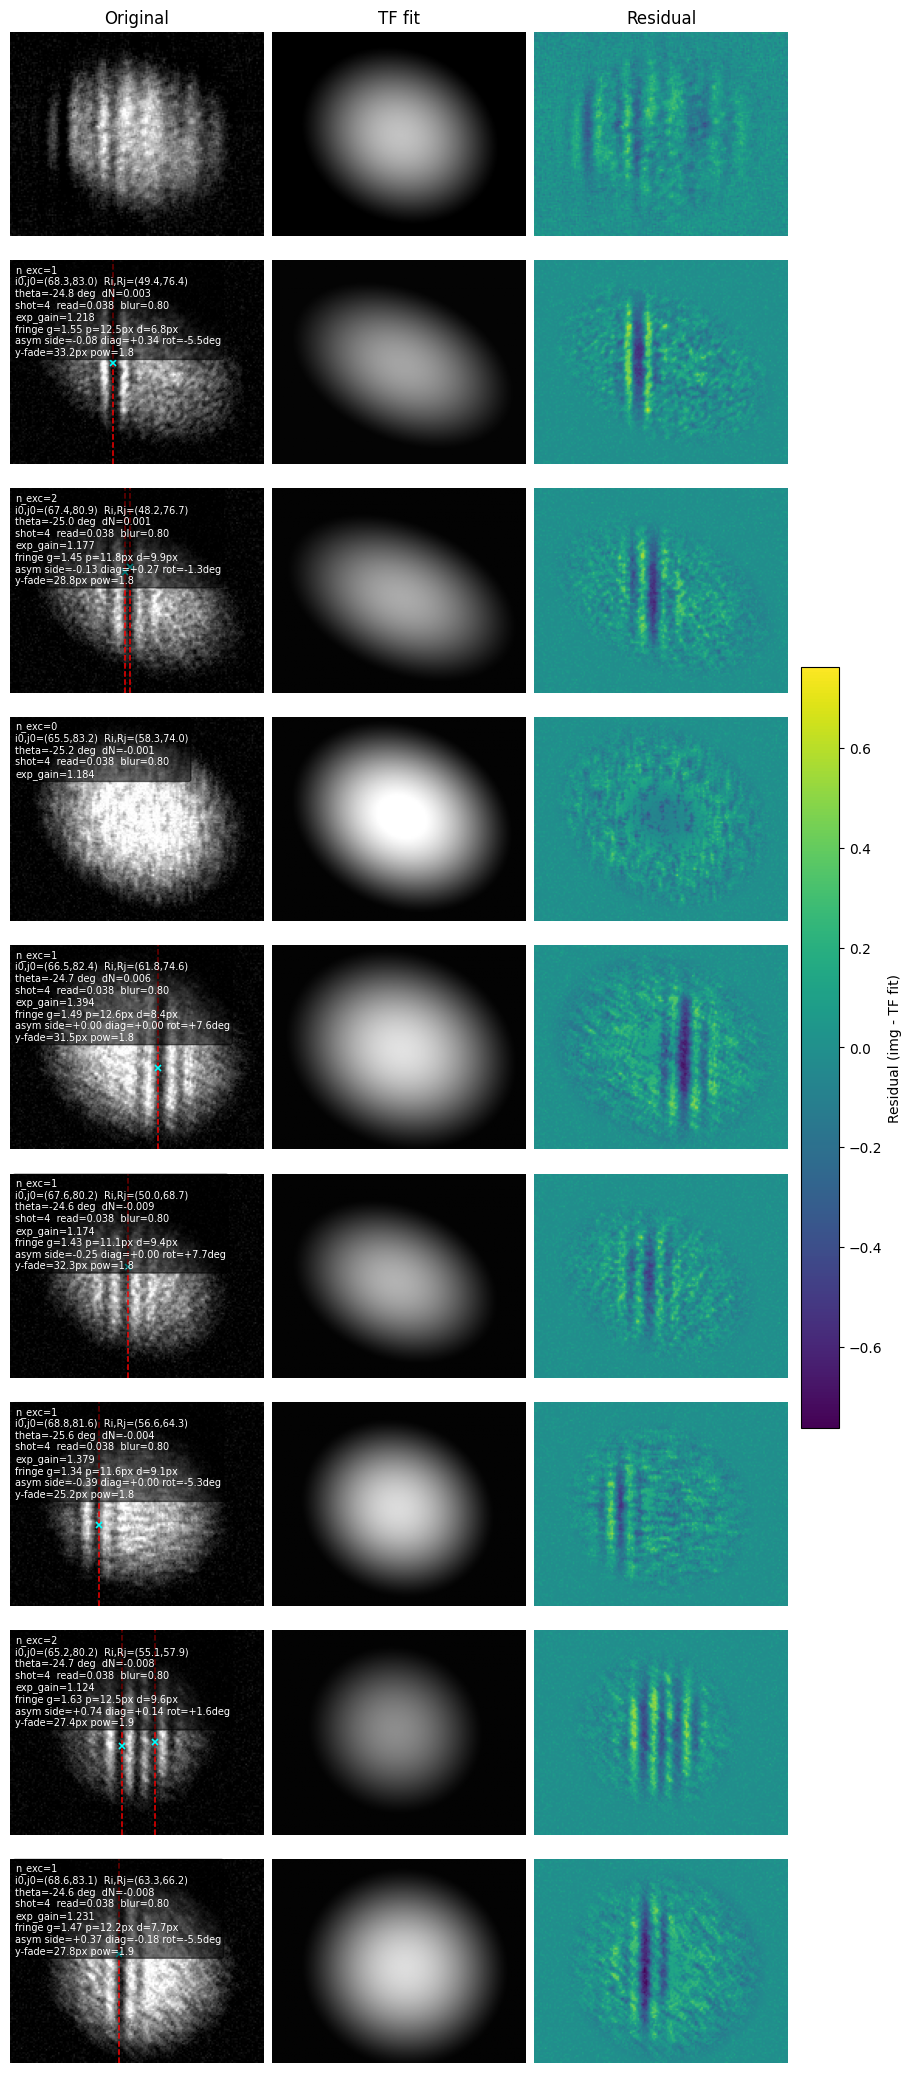

In [37]:
# Simulate images with short single-responsibility helpers
def build_shared_configs(gaussian_sigma):
    tf_sampling_config = {
        'n0_scale': (0.5, 1.5),
        'i0_shift': (-2.0, 2.0),
        'j0_shift': (-2.0, 2.0),
        'Ri_scale': (0.85, 1.15),
        'Rj_scale': (0.85, 1.15),
        'theta_shift': (-0.01, 0.01),
        'delta_n_shift': (-0.01, 0.01),
    }

    fresnel_config = {
        'wavelength': 780e-9,
        'pixel_size': 5.6e-6,
        'na': 0.22,
        'propagation_distance_range': (1.2e-3, 3.0e-3),
        'phase_scale_range': (0.6, 0.9),
        'blend_range': (0.6, 0.9),
    }

    exposure_config = {
        'base_gain_range': (0.9, 1.12),
        'overexposure_prob': 1.0,
        'overexposure_gain_range': (1.12, 1.42),
    }

    noise_config = {
        'shot_photons': 4,
        'read_noise_std': 0.038,
    }

    shift_config = {
        'max_shift_px': 6.0,
        'apply_prob': 0.9,
        'blend': 0.5,
    }

    blur_config = {
        'gaussian_sigma': gaussian_sigma,
    }

    return {
        'tf_sampling': tf_sampling_config,
        'fresnel': fresnel_config,
        'exposure': exposure_config,
        'noise': noise_config,
        'shift': shift_config,
        'blur': blur_config,
    }


def sample_soliton_count(rng):
    return int(rng.choice([0, 1, 2], p=[0.2, 0.6, 0.2]))


def build_soliton_config(n_sol):
    return {
        'enabled': n_sol > 0,
        'count': n_sol,
        'base_angle_rad': 0.0,
        'angle_jitter_deg': 1.0,
        'i_span': (-0.4, 0.4),
        'j_span': (-0.4, 0.4),
        'depth_range': (0.65, 0.80),
        'width_range': (0.8, 1.4),
        'fringe_gain_range': (1.3, 1.7),
        'fringe_period_range': (11.0, 13.0),
        'fringe_decay_range': (5.0, 10.0),
        'fringe_phase_range': (-0.02, 0.02),
        'side_antisym_prob': 0.75,
        'side_antisym_range': (-0.85, 0.85),
        'side_antisym_scale_range': (5.0, 15.0),
        'diag_antisym_prob': 0.55,
        'diag_antisym_range': (-0.4, 0.4),
        'diag_antisym_scale_range': (10.0, 22.0),
        'diag_angle_range': (-np.pi / 20.0, np.pi / 20.0),
        'y_fade_prob': 1.0,
        'y_fade_range': (25.0, 35.0),
        'y_fade_power_range': (1.7, 2.0),
    }


def simulate_and_fit_one(anchor_params, rng, cfg):
    n_sol = sample_soliton_count(rng)
    soliton_config = build_soliton_config(n_sol)

    sim, sim_meta = simulate_image(
        base_tf_params=anchor_params,
        image_shape=(IMAGE_HEIGHT, IMAGE_WIDTH),
        tf_sampling_config=cfg['tf_sampling'],
        soliton_config=soliton_config,
        fresnel_config=cfg['fresnel'],
        exposure_config=cfg['exposure'],
        noise_config=cfg['noise'],
        blur_config=cfg['blur'],
        shift_config=cfg['shift'],
        rng=rng,
    )

    _, sim_fit, sim_res = fit_thomas_fermi_image(sim)
    return sim, sim_fit, sim_res, sim_meta


def run_synthesis_batch(anchor_params, n_synth, rng, cfg):
    synth_images = []
    synth_fits = []
    synth_residuals = []
    synth_metadata = []

    for _ in range(n_synth):
        sim, sim_fit, sim_res, sim_meta = simulate_and_fit_one(anchor_params, rng, cfg)
        synth_images.append(sim)
        synth_fits.append(sim_fit)
        synth_residuals.append(sim_res)
        synth_metadata.append(sim_meta)

    return synth_images, synth_fits, synth_residuals, synth_metadata


def build_plot_stacks(anchor_img, anchor_fit, anchor_res, synth_images, synth_fits, synth_residuals, synth_metadata):
    row_labels = ['Anchor'] + [f'Synth {k}' for k in range(1, len(synth_images) + 1)]
    real_stack = [anchor_img] + synth_images
    fit_stack = [anchor_fit] + synth_fits
    res_stack = [anchor_res] + synth_residuals
    meta_stack = [None] + synth_metadata
    return row_labels, real_stack, fit_stack, res_stack, meta_stack


def format_metadata_lines(meta):
    tf = meta['tf']
    info_lines = [
        f"n_exc={meta['num_excitations']}",
        f"i0,j0=({tf['i0']:.1f},{tf['j0']:.1f})  Ri,Rj=({tf['Ri']:.1f},{tf['Rj']:.1f})",
        f"theta={tf['theta_deg']:.1f} deg  dN={tf['delta_n']:.3f}",
        f"shot={meta['shot_photons']}  read={meta['read_noise_std']:.3f}  blur={meta['gaussian_sigma']:.2f}",
        f"exp_gain={meta['exposure_gain']:.3f}",
    ]

    if meta['num_excitations'] > 0 and len(meta['solitons']) > 0:
        s0 = meta['solitons'][0]
        info_lines.append(
            f"fringe g={s0['fringe_gain']:.2f} p={s0['fringe_period_px']:.1f}px d={s0['fringe_decay_px']:.1f}px"
        )
        info_lines.append(
            f"asym side={s0['side_antisym']:+.2f} diag={s0['diagonal_antisym']:+.2f} rot={s0['diagonal_angle_deg']:+.1f}deg"
        )
        y_fade_label = 'off' if s0['y_fade_px'] is None else f"{s0['y_fade_px']:.1f}px"
        info_lines.append(f"y-fade={y_fade_label} pow={s0['y_fade_power']:.1f}")

    return info_lines


def annotate_metadata(ax, meta):
    info_lines = format_metadata_lines(meta)
    ax.text(
        0.02,
        0.98,
        '\n'.join(info_lines),
        transform=ax.transAxes,
        va='top',
        ha='left',
        fontsize=7,
        color='white',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='black', alpha=0.55),
    )


def annotate_solitons(ax, meta):
    if meta['num_excitations'] <= 0:
        return
    for sol in meta['solitons']:
        ax.axvline(sol['j'], color='red', linestyle='--', linewidth=1.1, alpha=0.95)
        ax.plot(sol['j'], sol['i'], marker='x', color='cyan', markersize=5, mew=1.2)


def plot_simulation_grid(row_labels, real_stack, fit_stack, res_stack, meta_stack):
    n_rows = len(row_labels)
    fig, axes = plt.subplots(n_rows, 3, figsize=(9.0, 2.3 * n_rows), constrained_layout=True)
    residual_limit = max(np.max(np.abs(r)) for r in res_stack)

    for r, (label, real_img, fit_img, res_img, meta) in enumerate(
        zip(row_labels, real_stack, fit_stack, res_stack, meta_stack)
    ):
        axes[r, 0].imshow(real_img, cmap='gray', vmin=0, vmax=1)
        axes[r, 1].imshow(fit_img, cmap='gray', vmin=0, vmax=1)
        residual_im = axes[r, 2].imshow(res_img, cmap='viridis', vmin=-residual_limit, vmax=residual_limit)

        for c in range(3):
            axes[r, c].axis('off')

        axes[r, 0].set_ylabel(label, rotation=90, fontsize=11, labelpad=12, va='center')

        if meta is not None:
            annotate_metadata(axes[r, 0], meta)
            annotate_solitons(axes[r, 0], meta)

    axes[0, 0].set_title('Original')
    axes[0, 1].set_title('TF fit')
    axes[0, 2].set_title('Residual')
    fig.colorbar(residual_im, ax=axes[:, 2], shrink=0.9, label='Residual (img - TF fit)')
    plt.show()


anchor_img = images[anchor_idx].squeeze()
anchor_params, anchor_fit, anchor_res = fit_thomas_fermi_image(anchor_img)

rng = np.random.default_rng(42)
n_synth = 8
gaussian_sigma = 0.8  # filter width in pixels (set 0 to disable)

configs = build_shared_configs(gaussian_sigma)
synth_images, synth_fits, synth_residuals, synth_metadata = run_synthesis_batch(
    anchor_params,
    n_synth,
    rng,
    configs,
)

row_labels, real_stack, fit_stack, res_stack, meta_stack = build_plot_stacks(
    anchor_img,
    anchor_fit,
    anchor_res,
    synth_images,
    synth_fits,
    synth_residuals,
    synth_metadata,
)

plot_simulation_grid(row_labels, real_stack, fit_stack, res_stack, meta_stack)

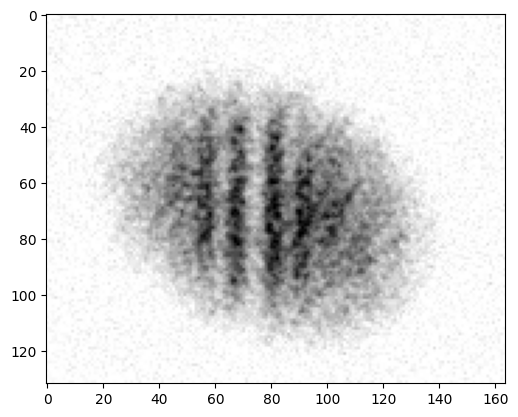

In [38]:
plt.imshow(synth_images[4], cmap='gray_r')